<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5136: Software Engineering</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 1: Git and Project Management</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Git - Verion Control System**

Git is a version control system: a tool that records every change made to a set of files over time. It answers three questions that are otherwise impossible to answer reliably on a shared project: what changed, who changed it, and can we go back?

Instead of keeping report_final.doc, report_final_v2.doc, and report_final_ACTUAL.doc, Git keeps one set of files plus a complete, navigable history behind them.

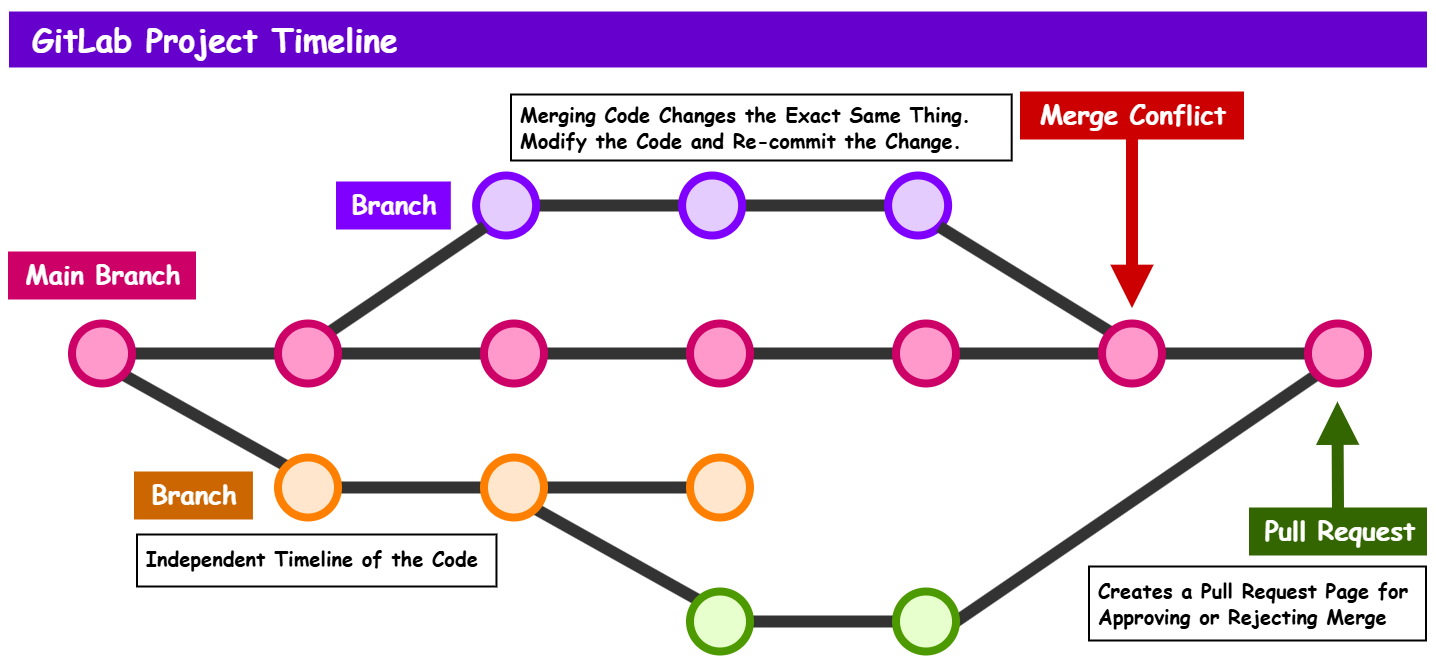


#### **Terminologies**

| Term | What it is | Git or platform |
|---|---|---|
| Repository (repo) | The project folder plus its entire history of changes | Git |
| Commit | A saved snapshot of changes with a descriptive message | Git |
| Branch | An independent line of development split off from another branch | Git |
| Merge | Combining a branch's commits back into another branch | Git |
| Merge conflict | Git stops because two branches edited the same lines and can't auto-decide | Git |
| Working directory | The actual files on your machine as you're editing them | Git |
| Staging area (index) | A holding zone where you pick which changes go into the next commit | Git |
| `git init` | Creates a brand-new repository in the current folder | Git |
| `git add` | Moves changes from the working directory into the staging area | Git |
| `git commit` | Saves the staged changes as a new snapshot in history | Git |
| `git status` | Shows what's changed, staged, and untracked right now | Git |
| `git log` | Displays the commit history | Git |
| `git diff` | Shows the exact line-by-line differences between two states | Git |
| `git checkout` / `git switch` | Moves you onto a different branch or an earlier commit | Git |
| `HEAD` | A pointer to the commit you're currently sitting on | Git |
| Remote | A copy of the repo hosted elsewhere, usually nicknamed `origin` | Git |
| `git clone` | Downloads a full copy of a remote repo, history included | Git |
| `git push` | Uploads your local commits to the remote | Git |
| `git fetch` | Downloads remote changes without applying them to your branch | Git |
| `git pull` | `fetch` + `merge` in one step | Git |
| `git rebase` | Replays your commits on top of another branch for a linear history | Git |
| `git stash` | Temporarily shelves uncommitted work so you can switch tasks | Git |
| `git revert` | Creates a new commit that undoes an earlier one, safely | Git |
| `git reset` | Moves your branch pointer backwards, optionally discarding changes | Git |
| Tag | A permanent label on a commit, typically a release like `v1.0` | Git |
| `.gitignore` | A file listing paths Git should never track (build output, secrets) | Git |
| Merge request / Pull request | A page to propose, review, and approve a merge — GitLab says "merge request", GitHub says "pull request" | Platform |
| Fork | Your own server-side copy of someone else's repo | Platform |
| Code review | Teammates commenting on and approving changes before merge | Platform |
| Issue | A tracked task, bug, or feature request | Platform |
| CI/CD pipeline | Automated builds and tests that run on each push | Platform |
| Protected branch | A branch rule blocking direct pushes, forcing review first | Platform |

***

### **Tutorial 1: Setting Up Python and GitLab**

**Source:** K. Tantithamthavorn, *Agentic Software Engineering: A Practical Guide for the AI-Native Engineer*, 2026
**Duration:** ~2 hours | **Format:** Individual or pairs | **Tools:** Python, Git, GitLab

### **Purpose**

Three things need to be in place before a first commit reaches a shared repository: a reproducible local environment, a protected branch, and a way to track what's being built. This tutorial sets up all three.

**Learning objectives:**

1. Create an isolated Python project with `uv` and set up pre-commit hooks
2. Write and run a Python script, and make well-structured Git commits
3. Configure a protected branch in GitLab and explain why teams need one
4. Write clear requirements with measurable acceptance criteria
5. Create a milestone, break a requirement into work items, and estimate effort
6. Read a burndown chart and link a merge request to a work item

---

### **Part A: Python Development Environment**

`pip` installs into whatever environment happens to be active, with no project isolation and no deterministic lockfile. Two developers running `pip install` against the same `requirements.txt` can end up with different transitive dependency versions — bugs that appear on one machine only.

| Capability | pip | uv |
|---|---|---|
| Install packages | Yes | Yes |
| Create virtual environments | No (needs `venv`) | Yes (`uv venv`) |
| Lockfile for reproducibility | No (manual) | Yes (`uv.lock`, autogenerated) |
| Manage Python versions | No | Yes (`uv python install`) |
| Project scaffold | No | Yes (`uv init`) |
| Speed | Baseline | 10–100× faster |

#### **Setup steps**

1. **Install `uv` and scaffold the project** — `uv init` generates `pyproject.toml`, a starter `hello.py`, and `.python-version`. Delete `hello.py`; create your own source files.
2. **Initialise Git** — write a `.gitignore` covering `.venv/`, `__pycache__/`, `*.pyc`, and `.env`, then commit it alongside `pyproject.toml` and `.python-version`.
3. **Add dev tooling** — `uv add --dev pre-commit` records the dependency under `[dependency-groups.dev]` and writes an exact `uv.lock`. Anyone cloning the repo runs `uv sync` for an identical environment.
4. **Configure pre-commit hooks** — a `.pre-commit-config.yaml` with `trailing-whitespace`, `end-of-file-fixer`, `check-yaml`, and `check-added-large-files`. If a hook modifies a file the commit aborts; stage the fix and commit again.
5. **Verify** — build a small `src/calculator.py` with `add()` and `divide()` (the latter raising `ValueError` on zero) and an `argparse` CLI, then run it end to end.

#### **About `pyproject.toml`**

The single configuration file for a modern Python project, defined in PEP 518 and PEP 621. It replaces the older patchwork of `setup.py`, `setup.cfg`, and `requirements.txt`, and is the authoritative record of what the project is and what it depends on.

#### **Conventional commit tags**

A good message has a subject line under 72 characters prefixed with a type tag, plus a body explaining *why* rather than *what*.

| Tag | Meaning |
|---|---|
| `feat` | A new feature or capability |
| `fix` | A bug fix |
| `chore` | Housekeeping — no production code change |
| `refactor` | Restructured code, unchanged behaviour |
| `test` | Adding or updating tests |
| `docs` | Documentation only |
| `ci` | CI/CD pipeline changes |

A log full of "fix stuff" and "update" is useless in review and impossible to search. Tags cost one word and pay back every time someone runs `git log --oneline`.

#### **What not to commit**

| Pattern | Reason |
|---|---|
| `.venv/` | Recreatable with `uv sync` |
| `__pycache__/`, `*.pyc` | Generated bytecode |
| `.env` | API keys and secrets — never commit credentials |
| `*.egg-info/` | Build artefacts |

`uv.lock` **should** be committed — it pins every dependency to an exact version so teammates and CI reproduce the same environment. Check staged files with `git diff --staged --name-only`; unstage a mistake with `git restore --staged .env`.

---

### **Part B: GitLab for Code Management**

A **protected branch** enforces rules about who can push directly and who must go through a reviewed merge request.

| Without protection | With protection |
|---|---|
| Anyone can push directly to `main` | Only maintainers (or no one) can |
| No code review required | All changes go through a merge request |
| CI/CD can be bypassed | Pipeline must pass before merging |
| Bugs reach production immediately | Reviewers and automated checks act as a gate |
| History can be rewritten via force push | History preserved — audit trail intact |

**Configuration:** Settings → Repository → Protected branches → select `main` → set *Allowed to push* and *Allowed to merge* → Protect.

Recommended for student teams:

| Setting | Value |
|---|---|
| Allowed to push | No one |
| Allowed to merge | Maintainers (or Developers + Maintainers) |

Force-push protection is enabled automatically on protected branches. The verification activity is to attempt a direct push to `main` and confirm the remote rejects it with a pre-receive hook error.

---

### **Part C: GitLab for Project Management**

The planning suite lives under the **Plan** menu and follows a top-down structure:

```
Requirements (WHAT) → Milestones (WHEN) → Work Items (HOW) → Merge Requests (THE CODE)
```

#### **1. Requirements**

Requirements describe a behaviour the product must exhibit. Unlike issues, they are long-lived artefacts that persist until archived or marked satisfied. A well-written one is **specific**, **testable**, **user-focused**, and **complete**.

- **Bad:** "The system should be user-friendly and perform well on the login page."
- **Good:** "As a registered user, I can reset my password by entering my email address and receiving a reset link within 2 minutes."

Descriptions should carry a user story plus a checklist of acceptance criteria — including edge cases like token expiry and suppressing errors on unregistered emails to prevent account enumeration.

#### **2. Milestones**

A time-boxed goal, a sprint, release, or project phase. Created via Plan → Milestones.

| Field | Required? | Purpose |
|---|---|---|
| Title | Yes | Identifies the milestone |
| Start date | Recommended | Left axis of the burndown chart |
| Due date | Recommended | Right axis (target completion) |
| Description | Optional | Sprint goal for the team |

Name milestones by goal, not number: *Sprint 1: User Authentication* beats *Sprint 1* when reviewing months later.

#### **3. Work items**

A single requirement typically breaks into several issues, each small enough to close in one or two days. A good breakdown means each issue has one clear deliverable, closing them all satisfies the requirement, and each references its parent for traceability.

- **Bad:** "Fix the login stuff"
- **Good:** "Implement POST /auth/reset-password API endpoint"

Issue descriptions should include implementation behaviour and a "Definition of Done" checklist. Assign a milestone in the sidebar; optionally add labels, an assignee, and a weight.

#### **4. Estimation**

Time tracking lives in the issue sidebar, set an *Estimated time* (`3h`, `1d`, `30m`) and log actual time via *Add time entry*. GitLab then shows estimated vs. actual, useful for retrospectives and calibrating future estimates.

**Issue weight** is a numeric effort score, similar to story points:

| Weight | Meaning |
|---|---|
| 1 | Trivial — a small tweak |
| 2–3 | Small — a few hours |
| 5 | Medium — a day or two |
| 8+ | Large — consider splitting |

Burndown charts can plot weight rather than issue count, which is more accurate when issue sizes vary.

#### **5. Burndown charts**

Generated automatically once issues are assigned to a milestone with start and due dates (Plan → Milestones → select milestone). The chart plots remaining open issues or total weight per day, with a dotted **ideal line** running from the Day 1 total to zero on the due date.

| Actual line vs. ideal | Meaning |
|---|---|
| Above | Behind schedule — more issues remain than expected |
| On | On track |
| Below | Ahead of schedule |
| Flat | Nothing closing — the team may be blocked |
| Sudden drop | Batched closures rather than continuous delivery |

</br>

| Chart | Shows | Best for |
|---|---|---|
| Burndown | Remaining work declining toward zero | Sprint completion progress |
| Burnup | Completed work rising, with total work as a second line | Identifying scope creep |

Burnup charts shine when scope changes mid-sprint: added issues push the total-work line up, making the increase immediately visible.

#### **6. Merge requests**

From an open issue, click **Create merge request**. GitLab creates a branch named after the issue (e.g. `12-implement-post-auth-reset-password`) and a draft MR. Work on the branch locally, push, then mark the MR **Ready**, assign a reviewer, and merge — the protected branch rule blocks merging until approval.

Adding a closing keyword to the MR description auto-closes the linked issue on merge and updates the burndown chart immediately:

```
Closes #12
```

Supported keywords: `Closes`, `Fixes`, `Resolves` (case-insensitive).

